# Statistik Portofolio V2-60 — Aset, Untung/Rugi per Aset, Pertumbuhan Modal

Strategi pilihan user: **V2-60** dengan modal **Rp1.500.000**.
- 8 coin: BTC, ETH, BNB, XRP, ADA, LINK, TRX, DOGE (≤10%); porsi inverse-volatilitas 60 hari.
- **60% modal di coin, 40% di USDT**. Filter pasar H8b (BTC > SMA100 atau FGI 14 hari > 50), else semua USDT.
- Rebalance tanggal 1 + saat filter berubah; transaksi < $5 dilewati (order minimum Binance).
- Periode **uji 2023-01 → 2026-06** (tidak dipakai saat memilih strategi). Biaya 0.15%/transaksi. Kurs Rp16.300.

⚠️ Ini **simulasi backtest**, bukan hasil trading nyata. Notebook ini juga mengekspor data untuk dashboard
(`notebooks/data/processed/v2_60_dashboard.json`).

In [1]:
import sys, json
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index
from research.single_position import Panel, BTC
from research.portfolio import run_portfolio, inverse_vol_weights

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
MODAL, KURS, MIN_ORDER = 1_500_000, 16_300, 5.0
PERIOD = ("2023-01-01", "2026-06-30")
UNIV = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "LINKUSDT", "TRXUSDT", "DOGEUSDT"]
P = Panel({s: load_symbol(s, "1d", "since2018") for s in UNIV}, "2018-01-01", "2026-06-30")
fgi = load_fear_greed_index()["fng_value"].reindex(P.dates).ffill()
btc = P.close[BTC]
market = ((btc > btc.rolling(100, min_periods=100).mean()) | (fgi.rolling(14).mean() > 50))
W = inverse_vol_weights(P, UNIV, 60, {"DOGEUSDT": 0.10}).mul(market.astype(float), axis=0) * 0.6
eq, info = run_portfolio(P, W, *PERIOD, capital_usd=MODAL / KURS, min_order_usd=MIN_ORDER)
rp = lambda x: x * MODAL                       # satuan simulasi (modal = 1.0) -> Rupiah
equity, values, cash = rp(eq), rp(info["values"]), rp(info["cash"])
pnl_daily = rp(info["pnl_daily"])
fills = info["fills"].assign(value=lambda d: rp(d["value"]), fee=lambda d: rp(d["fee"]))
names = {s: s[:-4] for s in UNIV}
print(f"Modal awal Rp{MODAL:,.0f} → nilai akhir Rp{equity.iloc[-1]:,.0f} ({equity.iloc[-1] / MODAL - 1:+.1%})")

Modal awal Rp1,500,000 → nilai akhir Rp3,776,236 (+151.7%)


## 1. Ringkasan

In [2]:
dd = equity / equity.cummax() - 1
mon = equity.resample("ME").last()
mon_ret = mon.pct_change()
mon_ret.iloc[0] = mon.iloc[0] / MODAL - 1
mon_pnl = mon.diff(); mon_pnl.iloc[0] = mon.iloc[0] - MODAL
yrs = (equity.index[-1] - equity.index[0]).days / 365.25

# "trade" per coin = satu periode memegang coin itu berturut-turut (masuk -> keluar)
episodes = []
for s in UNIV:
    held = values[s] > 1e-6
    grp = held.ne(held.shift()).cumsum()
    for _, g in held.groupby(grp):
        if not g.iloc[0]:
            continue
        a, b = g.index[0], g.index[-1]
        # hari keluar = hari setelah posisi terakhir (jual di open) jika masih dalam periode
        nxt = values.index[values.index.get_loc(b) + 1] if b != values.index[-1] else b
        pnl = pnl_daily.loc[a:nxt, s].sum() if b != values.index[-1] else pnl_daily.loc[a:b, s].sum()
        buys = fills[(fills.sym == s) & (fills.date == a) & (fills.value > 0)]
        entry_val = buys["value"].sum() if len(buys) else values.at[a, s]
        episodes.append(dict(coin=names[s], masuk=a.date(), keluar=(nxt if b != values.index[-1] else b).date(),
                             hari=(nxt - a).days if b != values.index[-1] else (b - a).days + 1,
                             modal_masuk=entry_val, untung_rugi=pnl, persen=pnl / entry_val if entry_val else np.nan,
                             status="selesai" if b != values.index[-1] else "masih dipegang"))
ep = pd.DataFrame(episodes).sort_values("masuk").reset_index(drop=True)

kpi = {
    "modal_awal": MODAL, "nilai_akhir": equity.iloc[-1], "profit_rp": equity.iloc[-1] - MODAL,
    "profit_pct": equity.iloc[-1] / MODAL - 1, "profit_per_tahun": (equity.iloc[-1] / MODAL) ** (1 / yrs) - 1,
    "max_drawdown_pct": dd.min(), "nilai_terendah": equity.min(), "tanggal_terendah": str(equity.idxmin().date()),
    "nilai_tertinggi": equity.max(),
    "bulan_untung_pct": (mon_pnl > 0).mean(), "bulan_terbaik_rp": mon_pnl.max(), "bulan_terburuk_rp": mon_pnl.min(),
    "rata2_bulan_rp": mon_pnl.mean(), "jumlah_transaksi": len(fills), "total_fee_rp": fills["fee"].sum(),
    "jumlah_trade": len(ep), "win_rate_trade": (ep.untung_rugi > 0).mean(),
    "rata2_untung_trade": ep.untung_rugi[ep.untung_rugi > 0].mean(), "rata2_rugi_trade": ep.untung_rugi[ep.untung_rugi <= 0].mean(),
    "hari_risk_on_pct": market.loc[PERIOD[0]:PERIOD[1]].mean(),
}
pd.Series(kpi).to_frame("nilai")

,nilai
modal_awal,1500000
nilai_akhir,3776235.733855
profit_rp,2276235.733855
profit_pct,1.51749
profit_per_tahun,0.302493
max_drawdown_pct,-0.192127
nilai_terendah,1500000.0
tanggal_terendah,2023-01-01
nilai_tertinggi,4590000.752613
bulan_untung_pct,0.452381


## 2. Untung/rugi per aset

In [3]:
per = []
for s in UNIV:
    e = ep[ep.coin == names[s]]
    per.append(dict(coin=names[s], untung_rugi=pnl_daily[s].sum(),
                    kontribusi=pnl_daily[s].sum() / (equity.iloc[-1] - MODAL),
                    trade=len(e), win_rate=(e.untung_rugi > 0).mean() if len(e) else np.nan,
                    rata2_hari=e.hari.mean() if len(e) else np.nan,
                    trade_terbaik=e.untung_rugi.max() if len(e) else np.nan,
                    trade_terburuk=e.untung_rugi.min() if len(e) else np.nan,
                    porsi_rata2_saat_risk_on=(values[s] / equity)[values.sum(axis=1) > 0].mean()))
per_coin = pd.DataFrame(per).set_index("coin").sort_values("untung_rugi", ascending=False)
out = per_coin.copy().astype(object)
for c in ("untung_rugi", "trade_terbaik", "trade_terburuk"):
    out[c] = per_coin[c].map(lambda v: f"Rp{v:,.0f}")
for c in ("kontribusi", "win_rate", "porsi_rata2_saat_risk_on"):
    out[c] = per_coin[c].map(lambda v: f"{v:.0%}")
out["rata2_hari"] = per_coin["rata2_hari"].map(lambda v: f"{v:.0f}")
out

,untung_rugi,kontribusi,trade,win_rate,rata2_hari,trade_terbaik,trade_terburuk,porsi_rata2_saat_risk_on
coin,,,,,,,,
XRP,"Rp458,733",20%,15,47%,61,"Rp416,988","Rp-54,754",6%
TRX,"Rp410,936",18%,16,62%,54,"Rp198,310","Rp-42,109",10%
BNB,"Rp408,160",18%,16,44%,54,"Rp236,331","Rp-33,217",8%
ADA,"Rp283,907",12%,16,25%,54,"Rp281,266","Rp-53,888",5%
BTC,"Rp226,971",10%,16,31%,54,"Rp145,246","Rp-39,518",9%
ETH,"Rp202,721",9%,16,25%,54,"Rp218,220","Rp-48,905",7%
DOGE,"Rp186,702",8%,9,44%,104,"Rp167,820","Rp-42,322",4%
LINK,"Rp98,107",4%,16,25%,49,"Rp119,486","Rp-41,176",5%


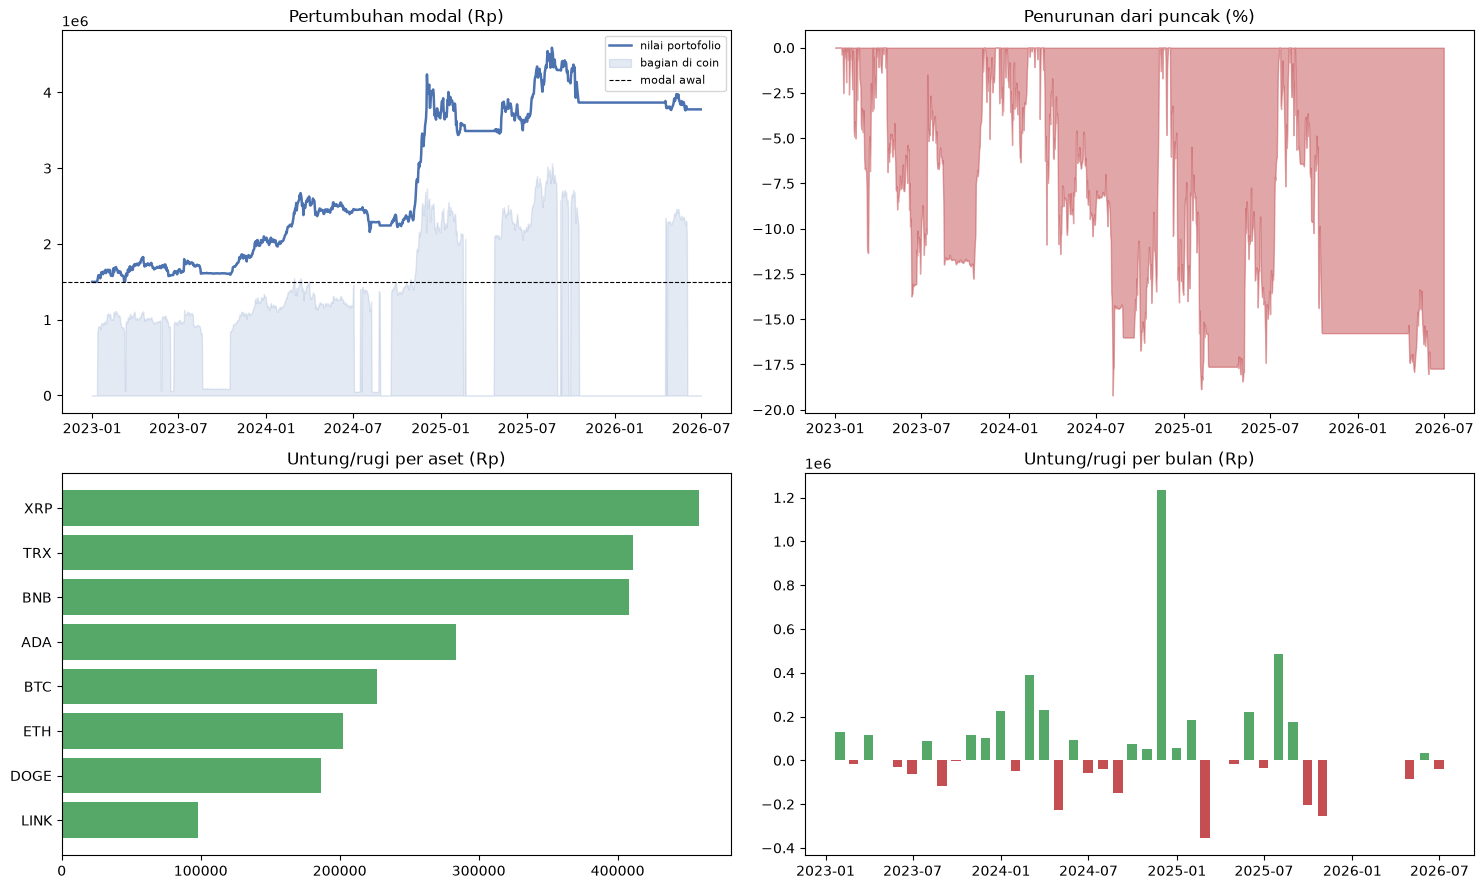

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
ax = axes[0, 0]
ax.plot(equity.index, equity, color="#4C72B0", lw=1.8, label="nilai portofolio")
ax.fill_between(values.index, 0, values.sum(axis=1), color="#4C72B0", alpha=0.15, label="bagian di coin")
ax.axhline(MODAL, color="black", lw=0.8, ls="--", label="modal awal")
ax.set_title("Pertumbuhan modal (Rp)"); ax.legend(fontsize=8)
ax = axes[0, 1]
ax.fill_between(dd.index, dd * 100, 0, color="#C44E52", alpha=0.5)
ax.set_title("Penurunan dari puncak (%)")
ax = axes[1, 0]
pc = per_coin["untung_rugi"]
ax.barh(pc.index[::-1], pc.values[::-1], color=np.where(pc.values[::-1] > 0, "#55A868", "#C44E52"))
ax.set_title("Untung/rugi per aset (Rp)")
ax = axes[1, 1]
ax.bar(mon_pnl.index, mon_pnl.values, width=20, color=np.where(mon_pnl > 0, "#55A868", "#C44E52"))
ax.set_title("Untung/rugi per bulan (Rp)")
plt.tight_layout(); plt.show()

## 3. Riwayat trade per aset (masuk → keluar)

In [5]:
show = ep.copy()
show["modal_masuk"] = show["modal_masuk"].map(lambda v: f"Rp{v:,.0f}")
show["untung_rugi"] = ep["untung_rugi"].map(lambda v: f"Rp{v:+,.0f}")
show["persen"] = ep["persen"].map(lambda v: f"{v:+.1%}")
print(f"{len(ep)} trade | untung {int((ep.untung_rugi > 0).sum())} | rugi {int((ep.untung_rugi <= 0).sum())}")
show.tail(20)

120 trade | untung 45 | rugi 75


,coin,masuk,keluar,hari,modal_masuk,untung_rugi,persen,status
100,BNB,2025-09-30,2025-10-18,18,"Rp346,464","Rp+12,855",+3.7%,selesai
101,LINK,2025-09-30,2025-10-18,18,"Rp172,814","Rp-41,176",-23.8%,selesai
102,XRP,2025-09-30,2025-10-18,18,"Rp265,368","Rp-54,754",-20.6%,selesai
103,ADA,2025-09-30,2025-10-18,18,"Rp236,637","Rp-53,888",-22.8%,selesai
104,BNB,2026-04-17,2026-04-20,3,"Rp324,251","Rp-11,005",-3.4%,selesai
105,LINK,2026-04-17,2026-04-20,3,"Rp205,137","Rp-12,137",-5.9%,selesai
106,ETH,2026-04-17,2026-04-20,3,"Rp208,399","Rp-8,147",-3.9%,selesai
107,XRP,2026-04-17,2026-04-20,3,"Rp291,810","Rp-12,647",-4.3%,selesai
108,TRX,2026-04-17,2026-04-20,3,"Rp586,616","Rp+1,823",+0.3%,selesai
109,DOGE,2026-04-17,2026-04-20,3,"Rp224,692","Rp-14,650",-6.5%,selesai


## 4. Ekspor data dashboard

In [6]:
weekly = equity.resample("W").last().index
alloc_m = values.resample("ME").mean().rename(columns=names)
alloc_m["USDT"] = cash.resample("ME").mean()
risk = market.loc[PERIOD[0]:PERIOD[1]]
blocks = []
for _, g in risk.groupby(risk.ne(risk.shift()).cumsum()):
    blocks.append({"mulai": str(g.index[0].date()), "akhir": str(g.index[-1].date()), "risk_on": bool(g.iloc[0])})
last = values.iloc[-1].rename(names)
data = {
    "meta": {"strategi": "V2-60", "modal": MODAL, "kurs": KURS, "periode": list(PERIOD),
             "aset": [names[s] for s in UNIV], "dibuat_dari": "notebooks/20_v2_60_portfolio_stats.ipynb"},
    "kpi": {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v) for k, v in kpi.items()},
    "equity": [{"t": str(d.date()), "total": round(float(equity.loc[:d].iloc[-1])), "coin": round(float(values.sum(axis=1).loc[:d].iloc[-1])),
                "dd": round(float(dd.loc[:d].iloc[-1]) * 100, 2)} for d in weekly],
    "alokasi_bulanan": [{"t": str(d.strftime("%Y-%m")), **{k: round(float(v)) for k, v in row.items()}} for d, row in alloc_m.iterrows()],
    "alokasi_akhir": {**{k: round(float(v)) for k, v in last.items()}, "USDT": round(float(cash.iloc[-1]))},
    "per_aset": [{"coin": c, **{k: (None if pd.isna(v) else float(v)) for k, v in row.items()}} for c, row in per_coin.iterrows()],
    "bulanan": [{"t": d.strftime("%Y-%m"), "rp": round(float(p)), "pct": round(float(r) * 100, 2)} for d, p, r in zip(mon_pnl.index, mon_pnl, mon_ret)],
    "trade": [{"coin": r.coin, "masuk": str(r.masuk), "keluar": str(r.keluar), "hari": int(r.hari),
               "modal_masuk": round(float(r.modal_masuk)), "untung_rugi": round(float(r.untung_rugi)),
               "persen": round(float(r.persen) * 100, 2), "status": r.status} for r in ep.itertuples()],
    "rezim": blocks,
}
out_path = PROJECT_ROOT / "notebooks" / "data" / "processed" / "v2_60_dashboard.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
print(f"Tersimpan: {out_path.relative_to(PROJECT_ROOT)} ({out_path.stat().st_size / 1024:.0f} KB)")
print("Alokasi terakhir (Rp):", data["alokasi_akhir"])

Tersimpan: notebooks\data\processed\v2_60_dashboard.json (44 KB)
Alokasi terakhir (Rp): {'BTC': 0, 'ETH': 0, 'BNB': 0, 'XRP': 0, 'ADA': 0, 'LINK': 0, 'TRX': 0, 'DOGE': 0, 'USDT': 3776236}


## Kesimpulan (simulasi V2-60, modal Rp1,5 juta, 2023-01 → 2026-06)

| | |
|---|---|
| Nilai akhir | **Rp3.776.236** (+151.7%, ±+30%/tahun) |
| Nilai tertinggi | Rp4.590.001 |
| Penurunan terbesar dari puncak | **−19.2%** |
| Nilai terendah | Rp1.500.000 (modal awal) — **tidak pernah di bawah modal awal** di periode ini |
| Bulan untung | 45% (bulan terbaik +Rp1,23 jt, terburuk −Rp355rb) |
| Transaksi | 275 order, total fee ±Rp86.900 |
| Trade (masuk→keluar per coin) | 120: **45 untung, 75 rugi (win rate 38%)**, rata-rata untung **Rp75rb** vs rugi **Rp15rb** |

- **Semua 8 aset menyumbang untung**: XRP Rp459rb, TRX Rp411rb, BNB Rp408rb, ADA Rp284rb, BTC Rp227rb,
  ETH Rp203rb, DOGE Rp187rb, LINK Rp98rb — diversifikasi bekerja, tidak bergantung satu coin.
- Pola khas strategi tren: **lebih sering rugi kecil, sesekali untung besar**.
- Rata-rata profit per bulan di sini (±Rp54rb) lebih besar dari notebook 19 (±Rp37rb) karena di sini modal
  **ikut bertumbuh** (bunga berbunga); notebook 19 menghitung dengan modal tetap Rp1,5 juta.
- Di akhir Juni 2026 filter pasar sedang **risk-off** → seluruh dana di USDT.

⚠️ Simulasi backtest, bukan jaminan hasil ke depan. Dashboard visual dibuat dari file JSON hasil notebook ini.